<a href="https://colab.research.google.com/github/aryan-s-08/learn-aiml/blob/main/Rainfall_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

/tmp/ipykernel_1214/1526951013.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})


Accuracy: 0.8389247903203629
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     22672
           1       0.71      0.46      0.56      6420

    accuracy                           0.84     29092
   macro avg       0.78      0.70      0.73     29092
weighted avg       0.83      0.84      0.83     29092

Confusion matrix:
 [[21454  1218]
 [ 3468  2952]]


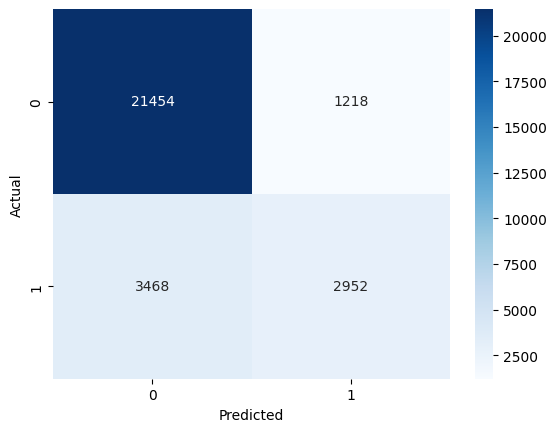

In [10]:
# !pip install kaggle

# #upload your kaggle.json file(API KEY)
# from google.colab import files
# files.upload()

# #Move the kaggle.json file to the correct location
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# #download the dataset to /content/data/
# !kaggle datasets download -d sharma/weather-dataset-rattle-package -p /content/data/

# #unzip the dataset to /content/data/
# !unzip /content/data/weather-dataset-rattle-package.zip -d /content/data/


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import os


df = pd.read_csv('data/weatherAUS.csv')

#explore data
print(df.head())
print(df.info())
print(df.describe())

# Impute missing values in 'RainToday' with its mode
# This is done early to ensure 'RainToday' is clean before being added to X and mapped.
if df['RainToday'].isnull().any():
    df['RainToday'] = df['RainToday'].fillna(df['RainToday'].mode()[0])

# Impute missing values in 'RainTomorrow' with its mode *before* mapping to numerical values for y
if df['RainTomorrow'].isnull().any():
    df['RainTomorrow'] = df['RainTomorrow'].fillna(df['RainTomorrow'].mode()[0])

imputer = SimpleImputer(strategy='mean')

# Select features, including the now-clean 'RainToday'
X = df[['MinTemp','MaxTemp','Rainfall','Evaporation','Sunshine','WindGustSpeed','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Cloud9am','Cloud3pm','Temp9am','Temp3pm']]

# Now map 'RainToday' to numerical (0/1) for X
X['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})

# Impute missing numerical values in X
X = imputer.fit_transform(X) #impute missing values in X

# Convert 'RainTomorrow' to 0 or 1 for target y (now it should not have NaNs)
y = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

#split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#build logistic regression model
model = LogisticRegression(solver='liblinear') # Adding solver for robustness

#train model
model.fit(X_train, y_train)

#make predictions on the test set
y_pred = model.predict(X_test)

#evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))



#visualise confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", conf_matrix)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()